In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

In [2]:
# Acquiring the MNIST dataset
X, Y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [3]:
# Normalizing the pixel values to be between 0 and 1
X = X.to_numpy()
X = X/255.0

# Converting the labels to integers and then one-hot encoding them
Y = Y.astype(int)
Y = pd.get_dummies(Y, dtype=int)
Y = Y.to_numpy()

In [4]:
# Verifying the shapes of the matrices
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

Shape of X: (70000, 784)
Shape of Y: (70000, 10)


In [5]:
# Initializing the weights and biases
w1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros((1, 128))
w2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

In [6]:
# Function definitions
def relu(Z):
    return np.maximum(0, Z)
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
def cross_entropy_loss(y, t):
    epsilon = 1e-15
    t = np.clip(t, epsilon, 1 - epsilon)
    return -np.sum(y * np.log(t))
def accuracy(y, t):
    y_true = np.argmax(y, axis=1)
    y_pred = np.argmax(t, axis=1)
    return np.mean(y_true == y_pred)


In [7]:
# Splitting the dataset into training, validation, and test sets
N = len(X)
indices = np.random.permutation(N)
X_shuffled = X[indices]
Y_shuffled = Y[indices]

train_end = int(0.70 * N)
val_end = int(0.85 * N)
X_train = X_shuffled[:train_end]
Y_train = Y_shuffled[:train_end]
X_val = X_shuffled[train_end:val_end]
Y_val = Y_shuffled[train_end:val_end]
X_test = X_shuffled[val_end:]
Y_test = Y_shuffled[val_end:]

In [8]:
# Training stage
epochs = 20
batch_size = 64
learning_rate = 0.1
epoch_losses = []
for epoch in range(epochs): # one epoch goes through all the training data once
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    Y_train = Y_train[indices]
    total_loss = 0.0
    for i in range(0, len(X_train), batch_size): # processing one batch at a time
        x = X_train[i:i+batch_size]
        y = Y_train[i:i+batch_size]
        # forward pass
        a1 = x@w1 + b1
        z = relu(a1)
        a2 = z@w2 + b2
        t = softmax(a2)
        # loss calculation
        loss = cross_entropy_loss(y, t)
        total_loss += loss
        # backward pass
        dE_da2 = t - y
        dE_dw2 = z.T @ dE_da2
        dE_db2 = np.sum(dE_da2, axis=0, keepdims=True)
        dE_dz = dE_da2 @ w2.T
        dE_da1 = dE_dz * (a1 > 0).astype(float)
        dE_dw1 = x.T @ dE_da1 
        dE_db1 = np.sum(dE_da1, axis=0, keepdims=True)      

        # weight and bias updates
        w2 -= learning_rate * dE_dw2/batch_size
        b2 -= learning_rate * dE_db2/batch_size
        w1 -= learning_rate * dE_dw1/batch_size
        b1 -= learning_rate * dE_db1/batch_size


    # reporting loss after each epoch
    average_loss = total_loss/len(X_train)
    print("Epoch", epoch+1, "Loss =", average_loss)
    epoch_losses.append(average_loss)

    # validation after every 5 epochs
    if (epoch+1) % 5 == 0:
        x = X_val
        y = Y_val
        z = relu(x@w1 + b1)
        t = softmax(z@w2 + b2)
        val_loss = cross_entropy_loss(y, t)/len(X_val)
        print("Validation Loss =", val_loss)
        val_acc = accuracy(y, t)
        print("Validation Accuracy =", val_acc)



Epoch 1 Loss = 0.5977642856671135
Epoch 2 Loss = 0.26810557543800884
Epoch 3 Loss = 0.20756802625767604
Epoch 4 Loss = 0.16618902625912493
Epoch 5 Loss = 0.1384078012512243
Validation Loss = 0.14907046912234226
Validation Accuracy = 0.9560952380952381
Epoch 6 Loss = 0.1175371902346843
Epoch 7 Loss = 0.10334751069558318
Epoch 8 Loss = 0.0911233783668452
Epoch 9 Loss = 0.0814508889977664
Epoch 10 Loss = 0.07269298188755939
Validation Loss = 0.10704516500882229
Validation Accuracy = 0.9664761904761905
Epoch 11 Loss = 0.06604941738542255
Epoch 12 Loss = 0.060172215382586665
Epoch 13 Loss = 0.05464389169179209
Epoch 14 Loss = 0.050457718742929716
Epoch 15 Loss = 0.04594773554143681
Validation Loss = 0.09127295700452699
Validation Accuracy = 0.9704761904761905
Epoch 16 Loss = 0.04218599613398913
Epoch 17 Loss = 0.03919425818992354
Epoch 18 Loss = 0.03608446593188946
Epoch 19 Loss = 0.03347128301452488
Epoch 20 Loss = 0.03074462500774512
Validation Loss = 0.08420623468936199
Validation Accura

In [9]:
# Testing stage
x = X_test
y = Y_test
z = relu(x@w1 + b1)
t = softmax(z@w2 + b2)
test_loss = cross_entropy_loss(y, t)/len(X_test)
print("Test Loss =", test_loss)
test_acc = accuracy(y, t)
print("Test Accuracy =", test_acc)


Test Loss = 0.08688521573606492
Test Accuracy = 0.9740952380952381


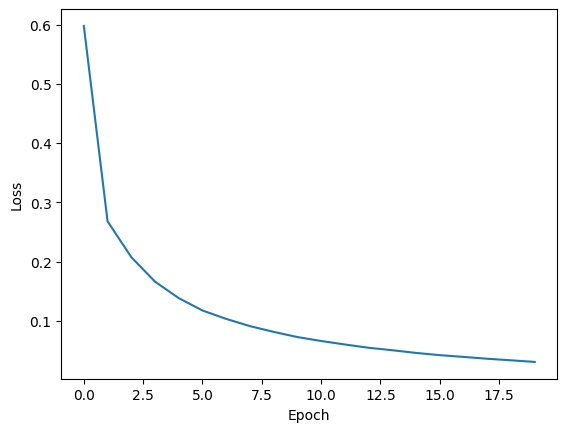

In [10]:
# Visualizing the loss over epochs
import matplotlib.pyplot as plt
plt.plot(epoch_losses)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()